# Биоинформатика, 2-й год, 2-й семестр. ДЗ 4. Махлин Мирон

In [1]:
import cooler
import cooltools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("seaborn-v0_8-white")
plt.rcParams["figure.figsize"] = (6, 5)

In [2]:
import cooler

path1, path2 = "data/4DNFI9W9Z575.mcool", "data/4DNFIJ2JKO7D.mcool"

cooler.fileops.list_coolers(path1)

['/resolutions/1000',
 '/resolutions/2000',
 '/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/25000',
 '/resolutions/50000',
 '/resolutions/100000',
 '/resolutions/250000',
 '/resolutions/500000',
 '/resolutions/1000000',
 '/resolutions/2500000',
 '/resolutions/5000000',
 '/resolutions/10000000']

In [3]:
clr1 = cooler.Cooler(f"{path1}::resolutions/25000")
clr2 = cooler.Cooler(f"{path2}::resolutions/25000")

### 5a
### 5b
(Балансировка применяется ниже, при вызове `clr.matrix(balance='KR').fetch(...)` или `balance=True`).

In [6]:
clr1.info

{'bin-size': 25000,
 'bin-type': 'fixed',
 'creation-date': '2024-12-05T07:14:51.695737',
 'format': 'HDF5::Cooler',
 'format-url': 'https://github.com/open2c/cooler',
 'format-version': 3,
 'generated-by': 'cooler-0.9.3',
 'genome-assembly': 'unknown',
 'metadata': {},
 'nbins': 123541,
 'nchroms': 24,
 'nnz': 56912713,
 'storage-mode': 'symmetric-upper',
 'sum': 98499768}

In [7]:
clr2.info

{'bin-size': 25000,
 'bin-type': 'fixed',
 'creation-date': '2024-12-05T05:38:31.862691',
 'format': 'HDF5::Cooler',
 'format-url': 'https://github.com/open2c/cooler',
 'format-version': 3,
 'generated-by': 'cooler-0.9.3',
 'genome-assembly': 'unknown',
 'metadata': {},
 'nbins': 123541,
 'nchroms': 24,
 'nnz': 24379490,
 'storage-mode': 'symmetric-upper',
 'sum': 39749863}

### 5c

In [4]:
pixels1 = clr1.pixels()[:10]
pixels2 = clr2.pixels()[:10]
print(pixels1)
print(pixels2)

   bin1_id  bin2_id  count
0        2    10358      1
1        2    20664      1
2        2    21691      1
3        2    31588      1
4        2    37883      1
5        2    43534      1
6        2    43845      1
7        2    43902      1
8        2    67156      1
9        2    81560      1
   bin1_id  bin2_id  count
0        2    27400      1
1        2    79091      1
2        2    93354      1
3        2    94371      1
4        2    94727      1
5        2    95416      1
6        2    95977      1
7        2    95997      1
8        2    96004      1
9        2   102423      1


**Ответ:** Как видно из вывода выше, таблица пикселей по умолчанию (полученная через `clr.pixels()`) содержит столбец `count` с целочисленными сырыми значениями, они не сбалансированы. Балансировка применяется позже с помощью `clr.matrix(balance=True)`.

### 5d

In [ ]:
! cooler dump data/4DNFI9W9Z575.mcool::resolutions/25000 | head -n 5

2	10358	1
2	20664	1
2	21691	1
2	31588	1
2	37883	1


### 5e

In [5]:
print(clr1.bins().columns.tolist())

['chrom', 'start', 'end', 'KR', 'VC', 'VC_SQRT', 'weight']


**Ответ:** Таблица с бинами содержит базовые координаты генома: `chrom` (хромосома), `start` (начало бина), `end` (конец бина). 
Также в ней присутствуют дополнительные столбцы, представляющие собой различные веса нормализации (балансировки), рассчитанные пайплайном 4DN: `KR`, `VC`, `VC_SQRT`, и дефолтный `weight`.

### 5f

INFO:root:creating a Pool of 15 workers
/home/ext.mmakhlin/miniforge3/envs/hic-env/lib/python3.11/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 15 workers
/home/ext.mmakhlin/miniforge3/envs/hic-env/lib/python3.11/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


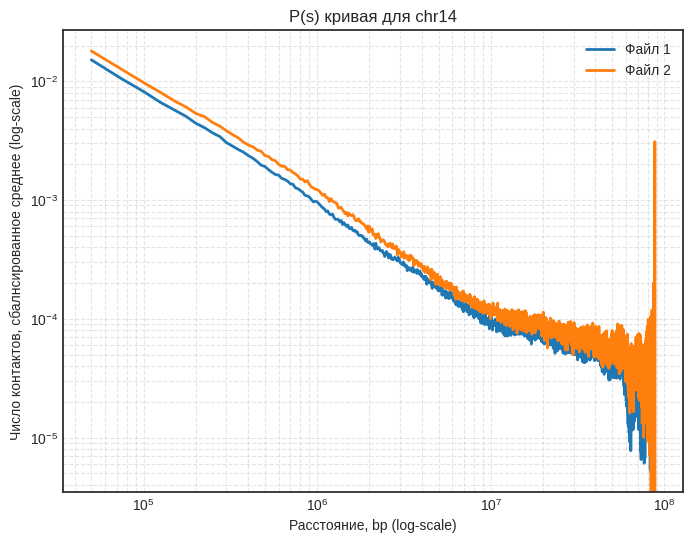

In [6]:
import bioframe
import cooltools

chrom = "chr14"
view_df = pd.DataFrame({
    'chrom': clr1.chromnames,
    'start': 0,
    'end': clr1.chromsizes.values,
    'name': clr1.chromnames
})
view_chr14 = view_df[view_df['chrom'] == chrom].reset_index(drop=True)

expected1 = cooltools.expected_cis(clr1, view_df=view_chr14, nproc=15)
expected2 = cooltools.expected_cis(clr2, view_df=view_chr14, nproc=15)

fig, ax = plt.subplots(figsize=(8, 6))
resolution = clr1.binsize

ax.plot(
    expected1['dist'] * resolution, 
    expected1['balanced.avg'], 
    label='Файл 1', 
    linewidth=2
)

ax.plot(
    expected2['dist'] * resolution, 
    expected2['balanced.avg'], 
    label='Файл 2', 
    linewidth=2
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Расстояние, bp (log-scale)')
ax.set_ylabel('Число контактов, сбалнсированное среднее (log-scale)')
ax.set_title(f'P(s) кривая для {chrom}')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()

**Ответ:** На графике выше (P(s) curve) видно падение вероятности контакта с увеличением расстояния. Кривая Файла 2 проходит чуть выше кривой Файла 1, что указывает на различия в компактизации хроматина между экспериментами.

### 5g
### 5h

INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers


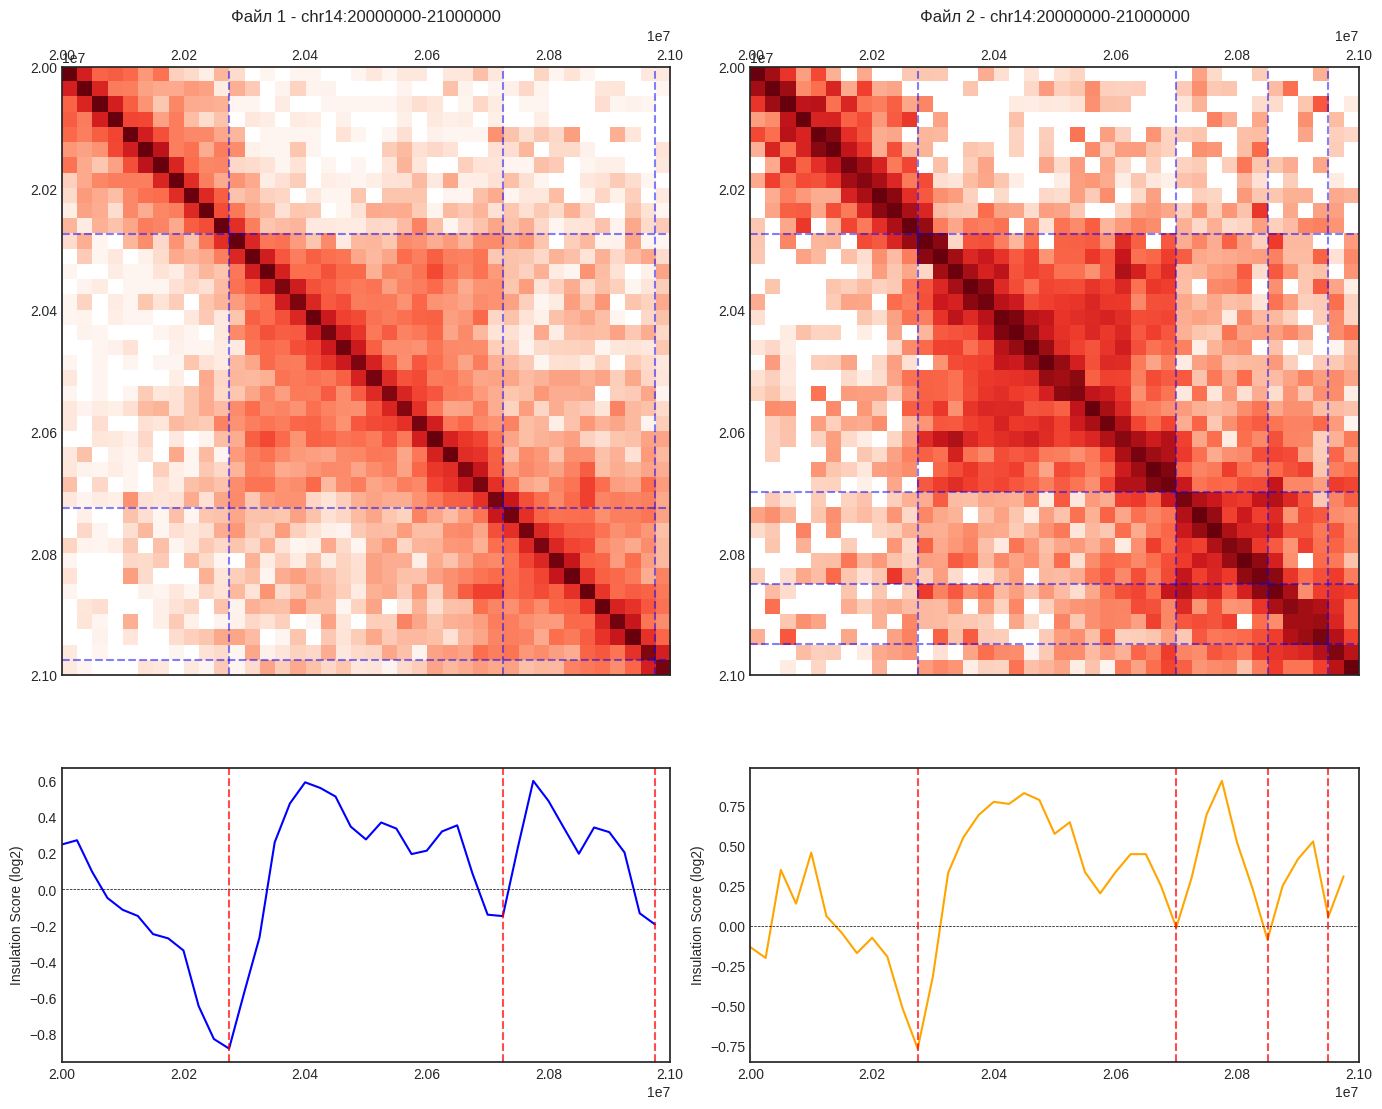

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

window_bp = 100000
insulation1 = cooltools.insulation(clr1, [window_bp], nproc=15)
insulation2 = cooltools.insulation(clr2, [window_bp], nproc=15)

region = 'chr14:20000000-21000000'
start_pos, end_pos = 20000000, 21000000

mat1_region = clr1.matrix(balance=True).fetch(region)
mat2_region = clr2.matrix(balance=True).fetch(region)

ins1_region = insulation1[(insulation1['chrom'] == 'chr14') & 
                          (insulation1['start'] >= start_pos) & 
                          (insulation1['end'] <= end_pos)]
ins2_region = insulation2[(insulation2['chrom'] == 'chr14') & 
                          (insulation2['start'] >= start_pos) & 
                          (insulation2['end'] <= end_pos)]

bounds1 = ins1_region[ins1_region[f'is_boundary_{window_bp}'] == True]
bounds2 = ins2_region[ins2_region[f'is_boundary_{window_bp}'] == True]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1]})

vmax1 = np.nanpercentile(mat1_region, 99)
img1 = axes[0, 0].matshow(mat1_region, cmap='Reds', norm=mcolors.LogNorm(vmin=0.001, vmax=vmax1), 
                          extent=(start_pos, end_pos, end_pos, start_pos))
axes[0, 0].set_title(f"Файл 1 - {region}")

for b in bounds1['start']:
    axes[0, 0].axvline(x=b, color='blue', linestyle='--', alpha=0.5)
    axes[0, 0].axhline(y=b, color='blue', linestyle='--', alpha=0.5)

axes[1, 0].plot(ins1_region['start'], ins1_region[f'log2_insulation_score_{window_bp}'], color='blue')
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=0.5)
for b in bounds1['start']:
    axes[1, 0].axvline(x=b, color='red', linestyle='--', alpha=0.7)
axes[1, 0].set_xlim(start_pos, end_pos)
axes[1, 0].set_ylabel("Insulation Score (log2)")


vmax2 = np.nanpercentile(mat2_region, 99)
img2 = axes[0, 1].matshow(mat2_region, cmap='Reds', norm=mcolors.LogNorm(vmin=0.001, vmax=vmax2), 
                          extent=(start_pos, end_pos, end_pos, start_pos))
axes[0, 1].set_title(f"Файл 2 - {region}")

for b in bounds2['start']:
    axes[0, 1].axvline(x=b, color='blue', linestyle='--', alpha=0.5)
    axes[0, 1].axhline(y=b, color='blue', linestyle='--', alpha=0.5)

axes[1, 1].plot(ins2_region['start'], ins2_region[f'log2_insulation_score_{window_bp}'], color='orange')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.5)
for b in bounds2['start']:
    axes[1, 1].axvline(x=b, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_xlim(start_pos, end_pos)
axes[1, 1].set_ylabel("Insulation Score (log2)")

plt.tight_layout()
plt.show()

**Ответ:** Видно, что тепловая карта для файла 2 более зашумлена в сравнении с файлом 1. Из-за этого профили insulation score отличаются в правой части графика (после координаты 2.07e7): для файла 2 было найдено на одну границу ТАДов больше.

### 5i

In [8]:
boundary_col = f'boundary_strength_{window_bp}'
score_col = f'boundary_strength_{window_bp}'

for bounds, name in [(bounds1, '4DNFI9W9Z575'), (bounds2, '4DNFIJ2JKO7D')]:
    bed = bounds[['chrom', 'start', 'end']].copy()
    bed['name'] = '.'
    bed['score'] = bounds[score_col].round(6)
    bed['strand'] = '.'
    bed.to_csv(f'tad_boundaries_{name}.bed', sep='\t', header=False, index=False)
    print(f"{len(bed)} границ для {name}")

3 границ для 4DNFI9W9Z575
4 границ для 4DNFIJ2JKO7D


### 5j

INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.


Файл 1, w=50000: 433 границ
Файл 1, w=100000: 199 границ
Файл 1, w=250000: 106 границ
Файл 1, w=500000: 73 границ
Файл 1, w=1000000: 48 границ
Файл 2, w=500000: 73 границ
Файл 2, w=50000: 434 границ
Файл 2, w=100000: 229 границ
Файл 2, w=1000000: 48 границ
Файл 2, w=250000: 121 границ


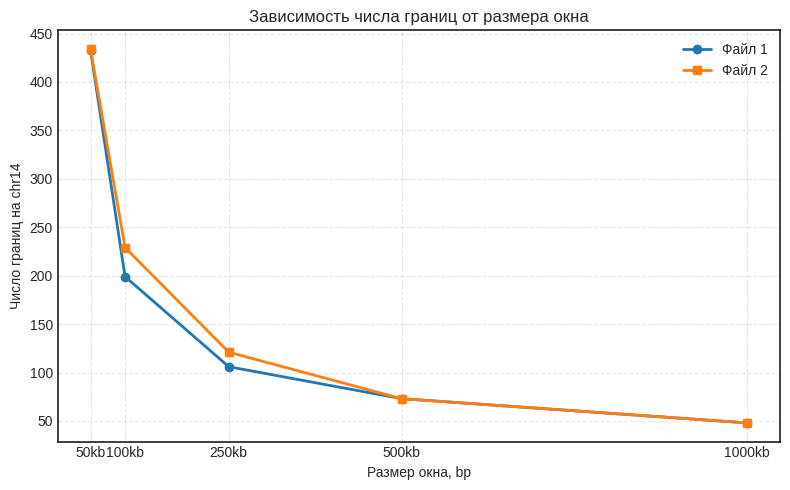

In [10]:
from concurrent.futures import ProcessPoolExecutor, as_completed

window_sizes = [50000, 100000, 250000, 500000, 1000000]

def count_boundaries(args):
    path, resolution, chrom, window = args
    import cooler, cooltools
    clr = cooler.Cooler(f"{path}::resolutions/{resolution}")
    ins = cooltools.insulation(clr, [window], nproc=1)
    n = ins[ins[f'is_boundary_{window}'] == True]['chrom'].eq(chrom).sum()
    return window, int(n)

tasks1 = [("data/4DNFI9W9Z575.mcool", 25000, "chr14", w) for w in window_sizes]
tasks2 = [("data/4DNFIJ2JKO7D.mcool", 25000, "chr14", w) for w in window_sizes]

counts1, counts2 = {}, {}

with ProcessPoolExecutor(max_workers=10) as exe:
    futs1 = {exe.submit(count_boundaries, t): t[3] for t in tasks1}
    futs2 = {exe.submit(count_boundaries, t): t[3] for t in tasks2}
    for f in as_completed(futs1):
        w, n = f.result(); counts1[w] = n; print(f"Файл 1, w={w}: {n} границ")
    for f in as_completed(futs2):
        w, n = f.result(); counts2[w] = n; print(f"Файл 2, w={w}: {n} границ")

ws = sorted(window_sizes)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ws, [counts1[w] for w in ws], 'o-', label='Файл 1', linewidth=2)
ax.plot(ws, [counts2[w] for w in ws], 's-', label='Файл 2', linewidth=2)
ax.set_xlabel("Размер окна, bp")
ax.set_ylabel("Число границ на chr14")
ax.set_title("Зависимость числа границ от размера окна")
ax.set_xticks(ws)
ax.set_xticklabels([f"{w//1000}kb" for w in ws])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Ответ:** Чем больше размер скользящего окна, тем меньше границ выявляется. Маленькие окна чувствительны к локальным структурам (суб-ТАДам и шуму), тогда как большие сглаживают их и выявляют только крупные, глобальные домены. Оба файла показывают идентичную динамику.

### На 9-10

Был использован инструмент `hicFindTADs` (HiCExplorer). На участке 1 Мб оба алгоритма нашли ровно по 3 границы ТАДов. Координаты границ практически идентичны (разница всего ~12-35 Кб, то есть около 1 бина), что подтверждает корректность выявленных топологических доменов.

In [13]:
!hicFindTADs -m data/4DNFI9W9Z575.mcool::resolutions/25000 --outPrefix hicexplorer_file1 --minDepth 75000 --maxDepth 1000000 --step 25000 --thresholdComparisons 0.05 --correctForMultipleTesting fdr --numberOfProcessors 15 --chromosomes chr14
!hicFindTADs -m data/4DNFIJ2JKO7D.mcool::resolutions/25000 --outPrefix hicexplorer_file2 --minDepth 75000 --maxDepth 1000000 --step 25000 --thresholdComparisons 0.05 --correctForMultipleTesting fdr --numberOfProcessors 15 --chromosomes chr14

INFO:hicexplorer.hicFindTADs:removing diagonal values

INFO:hicexplorer.hicFindTADs:Computing z-score matrix...

INFO:hicexplorer.hicFindTADs:Computing TAD-separation scores...

INFO:hicexplorer.hicFindTADs:computing spectrum for window sizes between 3 (75000 bp)and 40 (1000000 bp) at the following window sizes 1 [75000, 100000, 145710, 204903, 275000, 354508, 442423, 538006, 640685, 750000, 865569, 987071]

INFO:hicexplorer.hicFindTADs:Using 15 processors

INFO:hicexplorer.hicFindTADs:Computing p-values for window length: 75000

INFO:hicexplorer.hicFindTADs:FDR correction. Number of boundaries for delta 0.01, qval 0.05: 120
INFO:hicexplorer.hicFindTADs:removing diagonal values

INFO:hicexplorer.hicFindTADs:Computing z-score matrix...

INFO:hicexplorer.hicFindTADs:Computing TAD-separation scores...

INFO:hicexplorer.hicFindTADs:computing spectrum for window sizes between 3 (75000 bp)and 40 (1000000 bp) at the following window sizes 1 [75000, 100000, 145710, 204903, 275000, 354508, 4424

In [14]:
import pandas as pd

cooltools_bed = pd.read_csv('tad_boundaries_4DNFI9W9Z575.bed', sep='\t', header=None, names=['chrom', 'start', 'end', 'name', 'score', 'strand'])

hicexp_bed = pd.read_csv('hicexplorer_file1_boundaries.bed', sep='\t', header=None, names=['chrom', 'start', 'end', 'name', 'score', 'strand'])

hicexp_region = hicexp_bed[
    (hicexp_bed['chrom'] == 'chr14') & 
    (hicexp_bed['start'] >= 20000000) & 
    (hicexp_bed['end'] <= 21000000)
]

print(f"Число границ, найденных при помощи Cooltools: {len(cooltools_bed)}")
print(f"Число границ, найденных при помощи HiCExplorer: {len(hicexp_region)}")

print("\nГраницы Cooltools:")
print(cooltools_bed[['chrom', 'start', 'end']].to_string(index=False))

print("\nГраницы HiCExplorer:")
print(hicexp_region[['chrom', 'start', 'end']].to_string(index=False))

Число границ, найденных при помощи Cooltools: 3
Число границ, найденных при помощи HiCExplorer: 3

Границы Cooltools:
chrom    start      end
chr14 20275000 20300000
chr14 20725000 20750000
chr14 20975000 21000000

Границы HiCExplorer:
chrom    start      end
chr14 20262500 20287500
chr14 20687500 20712500
chr14 20962500 20987500
